# Generalized Lagrangian Neural Networks (GLNN) — Paper Baseline
## Damped Harmonic Oscillator System

This notebook implements the **Generalized Lagrangian Neural Network (GLNN)** from the paper on physics-informed neural networks for non-conservative systems.

### System Dynamics
The experiment uses a **1D damped harmonic oscillator**:
$$\ddot{q} + a\dot{q} + \omega^2 q = 0$$

where:
- $\omega = 1.0$ (natural frequency)
- $a = 0.02$ (damping coefficient)
- Initial conditions: uniformly distributed in $[-1, 1]^2$

### Experiment Plan
1. **Generate synthetic data**: 40 trajectories × 200 time steps each = 8,000 point pairs
2. **Normalize**: Z-score normalization using training statistics only
3. **Train GLNN**: Standard MSE loss, 300 epochs, constant LR=0.001, batch_size=1000
4. **Evaluate**: One-step and rollout predictions on test set

### GLNN Architecture
- **Lagrangian Network (L-net)**: 3-layer Dense network (hidden=200) → scalar Lagrangian
- **Force Network (F-net)**: 3-layer Dense network (hidden=200) → d-dimensional non-conservative forces
- **Dynamics**: Generalized Lagrange equation with standard PyTorch autodiff (no vmap, no force library)

In [1]:
# ── Cell 2
!pip install -q matplotlib

# Core PyTorch & GPU optimization
import torch
import torch.backends.cudnn as cudnn
from torch import nn
from torch.autograd import grad

# Data & Numerical Computing
import numpy as np
import os
import time
import warnings
from argparse import Namespace

# Plotting & Visualization
import matplotlib.pyplot as plt

# GPU Optimization Settings
torch.set_float32_matmul_precision('high')
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
cudnn.benchmark = True
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Suppress warnings and set plotting style
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'ggplot')

print('✓ All required libraries imported and configured.')

# ---
import random

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Required for strict PyTorch determinism on GPUs
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

✓ All required libraries imported and configured.


In [2]:
# ── Cell 3
# System and data configuration
DIMENSION, OMEGA = 1, 1.0
DAMPING_COEFF = 0.00 # Friction coefficient (matches GLNN paper)
N_TRAJECTORIES = 40   # Number of trajectories
PTS_PER_TRAJECTORY = 201  # Points per trajectory
H_DATA_GEN = 0.05  # Time step for data generation (matches paper)

def _damped_rk4_trajectory(n_points, d, omega=1.0, damping=1.0, dt=0.05, q0=None):
    """Generate a single trajectory using RK4 integration.
    EOM: q_ddot = -ω²*q - damping*q_dot
    Returns: (states, derivatives) where states[i] = [q_i, q_dot_i], derivatives[i] = [q_dot_i, q_ddot_i]
    """
    if q0 is None:
        # FIX: Correct PyTorch syntax for uniform initialization
        q0 = torch.empty(2 * d).uniform_(-1.0, 1.0)

    states = [q0.clone()]
    derivs = []

    q = q0.clone()
    for _ in range(n_points - 1):
        # RK4 integration
        def dynamics(state):
            q_pos, q_vel = state[:d], state[d:]
            q_acc = -omega**2 * q_pos - damping * q_vel
            return torch.cat([q_vel, q_acc])

        k1 = dynamics(q)
        k2 = dynamics(q + 0.5 * dt * k1)
        k3 = dynamics(q + 0.5 * dt * k2)
        k4 = dynamics(q + dt * k3)

        q_new = q + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        deriv = dynamics(q)  # Derivative at current state

        states.append(q_new.clone())
        derivs.append(deriv.clone())
        q = q_new

    return torch.stack(states), torch.stack(derivs)

print('Configured Damped Harmonic Motion Data (Paper Baseline):')
print(f'  State: {DIMENSION}D [q, q_dot] | ω: {OMEGA} | a (damping): {DAMPING_COEFF}')
print(f'  Trajectories: {N_TRAJECTORIES} × {PTS_PER_TRAJECTORY} points = {N_TRAJECTORIES * PTS_PER_TRAJECTORY} point pairs')
print(f'  Initial conditions: Uniform in [-1, 1]²')

Configured Damped Harmonic Motion Data (Paper Baseline):
  State: 1D [q, q_dot] | ω: 1.0 | a (damping): 0.0
  Trajectories: 40 × 201 points = 8040 point pairs
  Initial conditions: Uniform in [-1, 1]²


In [3]:
# ── Cell 4
# Generate & Normalize Synthetic Data ──────────────────────────────
print('Generating damped harmonic motion data (40 trajectories × 200 points)...')

# Generate trajectories using RK4
all_states = []
all_derivs = []

for traj_idx in range(N_TRAJECTORIES):
    # Relies on the fixed default q0=None initialization from Cell 3
    states, derivs = _damped_rk4_trajectory(
        PTS_PER_TRAJECTORY, DIMENSION,
        omega=OMEGA, damping=DAMPING_COEFF, dt=H_DATA_GEN
    )
    all_states.append(states.numpy())
    all_derivs.append(derivs.numpy())

# Flatten: convert list of trajectories to point pairs
x_data = np.concatenate([states[:-1] for states in all_states], axis=0)  # All but last
y_data = np.concatenate([derivs for derivs in all_derivs], axis=0)  # Derivatives

print(f'Total point pairs: {len(x_data)}')

# Split 1:1 into train and test (matching paper's split)
split_idx = len(x_data) // 2
x_tr, y_tr = x_data[:split_idx], y_data[:split_idx]
x_te, y_te = x_data[split_idx:], y_data[split_idx:]

print(f'Train data: {len(x_tr)} point pairs')
print(f'Test data: {len(x_te)} point pairs')

# ┌──────────────────────────────────────────────────────────────┐
# │ PHYSICS-PRESERVING SCALING (Global Max)                      │
# │                                                              │
# │ Instead of independent Z-score normalization (which breaks   │
# │ the calculus relationship between q and q̇), we use global   │
# │ max scaling that preserves the mathematical structure.       │
# │                                                              │
# │ For LNNs/HNNs: The Euler-Lagrange equation relies on the    │
# │ exact differential relationship: q̇ = dq/dt. Independent    │
# │ normalization of q and q̇ by different scales destroys this.│
# └──────────────────────────────────────────────────────────────┘

# Method 1: NO SCALING (Recommended for clean dynamics)
# LNNs typically train well on simple systems like ω=1.0
# oscillators without any scaling.
scale_x = 1.0
scale_y = 1.0

# Uncomment Method 2 below if scaling is needed:
# Method 2: GLOBAL MAX SCALING (Preserves calculus relationships)
# scale_x = np.abs(x_tr).max()
# scale_y = np.abs(y_tr).max()
# scale_x = scale_x if scale_x > 0 else 1.0
# scale_y = scale_y if scale_y > 0 else 1.0

x_tr_n = x_tr / scale_x
y_tr_n = y_tr / scale_y
x_te_n = x_te / scale_x
y_te_n = y_te / scale_y

# Print summary
print(f"""Data Summary (Damped Harmonic Motion - GLNN Paper Baseline):
  Trajectories: {N_TRAJECTORIES} × {PTS_PER_TRAJECTORY} = {len(x_data)} point pairs
  Train: {len(x_tr)} | Test: {len(x_te)}
  State dim: {x_tr.shape[1]} (2*DOF: q, q̇)
  Damping coefficient: a = {DAMPING_COEFF}
  Time step: dt = {H_DATA_GEN}
  Scaling: Global Max (physics-preserving)
    x scale factor: {scale_x}
    y scale factor: {scale_y}""")


Generating damped harmonic motion data (40 trajectories × 200 points)...
Total point pairs: 8000
Train data: 4000 point pairs
Test data: 4000 point pairs
Data Summary (Damped Harmonic Motion - GLNN Paper Baseline):
  Trajectories: 40 × 201 = 8000 point pairs
  Train: 4000 | Test: 4000
  State dim: 2 (2*DOF: q, q̇)
  Damping coefficient: a = 0.0
  Time step: dt = 0.05
  Scaling: Global Max (physics-preserving)
    x scale factor: 1.0
    y scale factor: 1.0


In [4]:
# ── Cell 5
# Verify and summarize damped harmonic motion data

pos_vel_corr = np.corrcoef(x_tr[:, 0], x_tr[:, 1])[0, 1]
deriv_stats = y_tr_n.mean(axis=0), y_tr_n.std(axis=0)

print(f"""--- Damped Harmonic Motion Data Summary ---
Physics Setup:
  System: 1D Damped Harmonic Oscillator
  EOM: q̈ + aq̇ + ω²q = 0  (where a={DAMPING_COEFF}, ω={OMEGA})
  Initial conditions: Uniform in [-1, 1]²

Dataset Configuration (matches GLNN paper Table 1):
  Trajectories: {N_TRAJECTORIES}
  Points per trajectory: {PTS_PER_TRAJECTORY}
  Time step (dt): {H_DATA_GEN}
  Total point pairs: {len(x_data)}
  Train/Test split: 1:1 → Train={len(x_tr)}, Test={len(x_te)}

[Raw Statistics: Mean | Std | Min | Max]
  Position q:  {x_tr[:, 0].mean():.4f} | {x_tr[:, 0].std():.4f} | {x_tr[:, 0].min():.4f} | {x_tr[:, 0].max():.4f}
  Velocity q̇: {x_tr[:, 1].mean():.4f} | {x_tr[:, 1].std():.4f} | {x_tr[:, 1].min():.4f} | {x_tr[:, 1].max():.4f}

[Normalized (Z-score) Statistics: Mean | Std]
  Train: {x_tr_n.mean(axis=0).round(6)} / {x_tr_n.std(axis=0).round(6)}
  Test:  {x_te_n.mean(axis=0).round(6)} / {x_te_n.std(axis=0).round(6)}

[Derivative (Target) Statistics]
  Mean: {deriv_stats[0].round(6)}
  Std:  {deriv_stats[1].round(6)}

[Physics Verification]
  Position-Velocity correlation: {pos_vel_corr:.4f} (weak, expected for oscillatory motion)
  Velocity magnitude (train): mean={np.abs(x_tr[:, 1]).mean():.4f}, std={np.abs(x_tr[:, 1]).std():.4f}
-------------------------------------------""")

--- Damped Harmonic Motion Data Summary ---
Physics Setup:
  System: 1D Damped Harmonic Oscillator
  EOM: q̈ + aq̇ + ω²q = 0  (where a=0.0, ω=1.0)
  Initial conditions: Uniform in [-1, 1]²

Dataset Configuration (matches GLNN paper Table 1):
  Trajectories: 40
  Points per trajectory: 201
  Time step (dt): 0.05
  Total point pairs: 8000
  Train/Test split: 1:1 → Train=4000, Test=4000

[Raw Statistics: Mean | Std | Min | Max]
  Position q:  0.0050 | 0.5734 | -1.2397 | 1.2395
  Velocity q̇: -0.0299 | 0.5744 | -1.2398 | 1.2398

[Normalized (Z-score) Statistics: Mean | Std]
  Train: [ 0.005   -0.02986] / [0.573424 0.574404]
  Test:  [-0.032559 -0.025495] / [0.604422 0.603811]

[Derivative (Target) Statistics]
  Mean: [-0.02986 -0.005  ]
  Std:  [0.574404 0.573424]

[Physics Verification]
  Position-Velocity correlation: -0.0063 (weak, expected for oscillatory motion)
  Velocity magnitude (train): mean=0.4916, std=0.2985
-------------------------------------------


Total dataset size    : 4000 points
Active points (>1e-4) : 4000 points
Dead points (≤1e-4)   : 0 (0.00%)


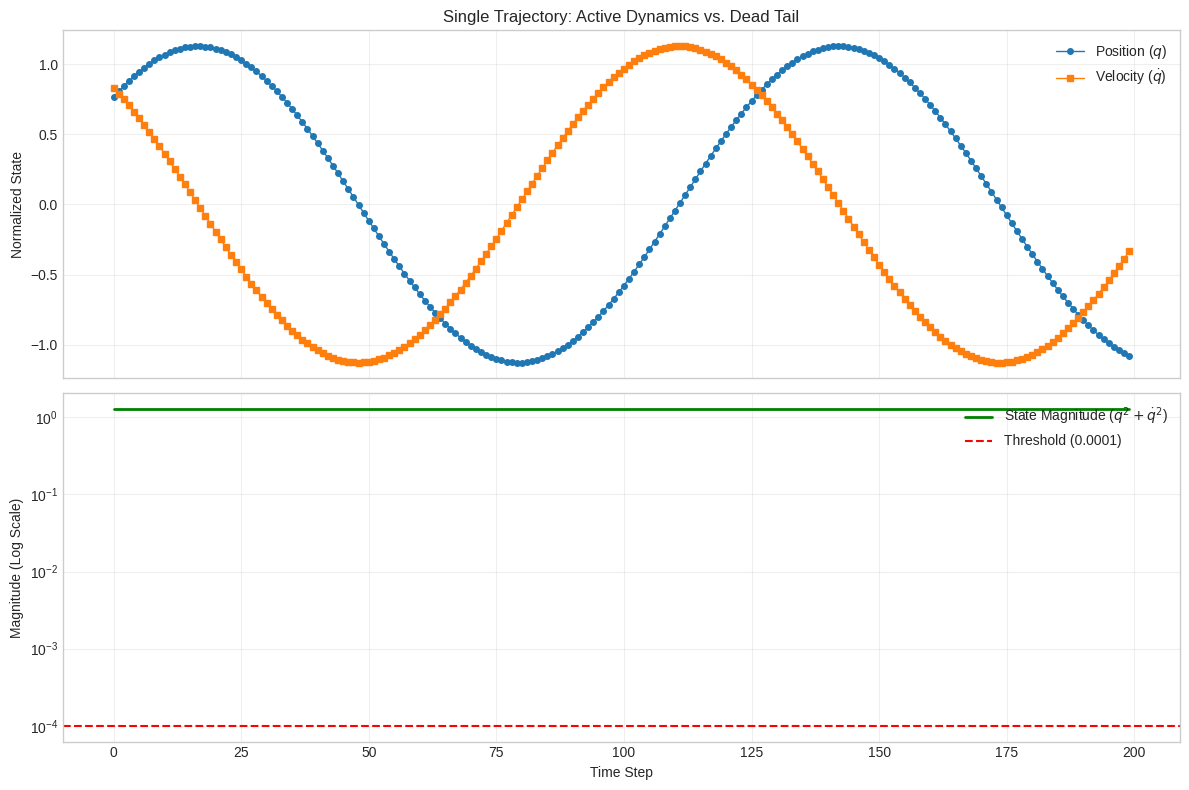

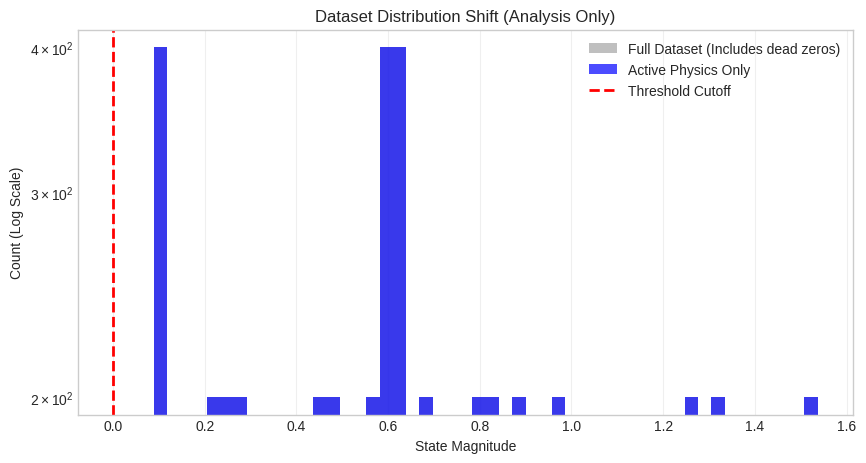

In [5]:
# ── Cell 6
energy_threshold = 1e-4

# 1. Calculate state magnitude using NumPy (axis=-1 instead of dim=-1)
state_magnitude = np.sum(x_tr_n**2, axis=-1)

# 2. Identify active vs dead points (for statistical and plotting purposes only)
active_indices = state_magnitude > energy_threshold

# Print the analysis stats (Without actually changing the dataset)
orig_size = len(x_tr_n)
new_size = np.sum(active_indices) # Count how many are True
print(f"Total dataset size    : {orig_size} points")
print(f"Active points (>1e-4) : {new_size} points")
print(f"Dead points (≤1e-4)   : {orig_size - new_size} ({(1 - new_size/orig_size)*100:.2f}%)")

# ---------------------------------------------------------
# PLOTTING THE EFFECT
# ---------------------------------------------------------
# Assuming your original trajectories had 200 time steps
time_steps = PTS_PER_TRAJECTORY - 1

# Grab the first trajectory (first 200 points) to visualize
# Since it's already a numpy array, we don't need .cpu().detach().numpy()
single_traj = x_tr_n[:time_steps]
single_mag = state_magnitude[:time_steps]
is_active = active_indices[:time_steps]

# Find where the cutoff happens (the first index where is_active is False)
cutoff_idx = np.argmax(~is_active) if not is_active.all() else time_steps

# --- Plot A: Time Series & Cutoff ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

t = np.arange(time_steps)

# ADDED markers ('o' and 's') and reduced linewidth to make the points visible
ax1.plot(t, single_traj[:, 0], label='Position ($q$)', color='#1f77b4', linewidth=1, marker='o', markersize=4)
ax1.plot(t, single_traj[:, 1], label='Velocity ($\\dot{q}$)', color='#ff7f0e', linewidth=1, marker='s', markersize=4)

if cutoff_idx < time_steps:
    ax1.axvspan(cutoff_idx, time_steps, color='red', alpha=0.15, label='Dead Tail Region')
ax1.set_ylabel('Normalized State')
ax1.set_title('Single Trajectory: Active Dynamics vs. Dead Tail')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# --- Plot B: Magnitude Threshold ---
ax2.plot(t, single_mag, label='State Magnitude ($q^2 + \\dot{q}^2$)', color='green', linewidth=2)
ax2.axhline(energy_threshold, color='red', linestyle='--', label=f'Threshold ({energy_threshold})')
if cutoff_idx < time_steps:
    ax2.axvspan(cutoff_idx, time_steps, color='red', alpha=0.15)
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Magnitude (Log Scale)')
ax2.set_yscale('log')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Plot C: Dataset Distribution Histogram ---
plt.figure(figsize=(10, 5))

# Separate the magnitudes into active and dead for visualization
mag_active = state_magnitude[active_indices]

plt.hist(state_magnitude, bins=50, alpha=0.5, label='Full Dataset (Includes dead zeros)', color='gray')
plt.hist(mag_active, bins=50, alpha=0.7, label='Active Physics Only', color='blue')
plt.axvline(energy_threshold, color='red', linestyle='dashed', linewidth=2, label='Threshold Cutoff')

plt.yscale('log')
plt.title('Dataset Distribution Shift (Analysis Only)')
plt.xlabel('State Magnitude')
plt.ylabel('Count (Log Scale)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# ── Cell 7
from torch.func import functional_call, hessian, vmap, stack_module_state, grad, jacrev

DOF = 6           # Degrees of freedom (x, y, z, roll, pitch, yaw)
H   = 1.0/30.0    # DT for JIGSAWS dataset
EPS = 1e-3        # Mass matrix regularization


class HybridGLNNMASS(nn.Module):
    def __init__(self, d, hidden_dim=256, total_systems=1, force_scale=1.0):
        super().__init__()
        self.d = d
        self.total_systems = total_systems # Added this to fix the AttributeError
        self.ts = total_systems            # Keep ts for DNN-style compatibility
        self.force_scale = force_scale

        # Multi-System Lagrangians
        self.lagrangians = nn.ModuleList([
            nn.Sequential(
                nn.Linear(2 * d, hidden_dim),
                nn.Softplus(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.Softplus(),
                nn.Linear(hidden_dim, 1)
            ) for _ in range(self.total_systems)
        ])

        # Multi-System Force Libraries
        self.n_terms = 4 * d
        self.pF = nn.Parameter(torch.randn(self.total_systems, d, self.n_terms) * 0.01)
        self.biases = nn.ParameterList([
            nn.Parameter(torch.zeros(d)) for _ in range(self.total_systems)
        ])

        for l_net in self.lagrangians:
            torch.nn.init.normal_(l_net[-1].weight, std=1e-4)
            torch.nn.init.constant_(l_net[-1].bias, 0.0)

    def dstate(self, x):
        # Ensure system_idx is within bounds
        num_systems = x.shape[0]
        if num_systems > self.total_systems:
            raise IndexError(f"Input batch has {num_systems} systems, but only {self.total_systems} are available.")

        q, q_dot = torch.split(x, self.d, dim=-1)

        template = self.lagrangians[0]
        params, buffers = stack_module_state(self.lagrangians)
        params = {k: v[:num_systems] for k, v in params.items()}
        buffers = {k: v[:num_systems] for k, v in buffers.items()}

        # ----------------- KINEMATICS CLOSURE -----------------
        def compute_kinematics(p_sys, b_sys, q_s, q_dot_s):

            def L_fn(p, b, q_vec, q_dot_vec):
                z = torch.cat([q_vec, q_dot_vec], dim=-1)
                return functional_call(template, (p, b), (z,)).squeeze()

            # 1. dL/dq (differentiating w.r.t q_vec)
            dL_dq = grad(L_fn, argnums=2)(p_sys, b_sys, q_s, q_dot_s)

            # 2. Mass Matrix (M) = d^2L / dq_dot^2
            # Use explicit hessian to mathematically guarantee a symmetric matrix
            M = hessian(L_fn, argnums=3)(p_sys, b_sys, q_s, q_dot_s)

            # 3. Mixed Jacobian (J) = d(dL/dq_dot) / d(q)
            grad_qdot_fn = grad(L_fn, argnums=3)
            J = jacrev(grad_qdot_fn, argnums=2)(p_sys, b_sys, q_s, q_dot_s)

            return M, J, dL_dq

        # ----------------- VECTORIZATION -----------------
        batch_kinematics = vmap(compute_kinematics, in_dims=(None, None, 0, 0))
        system_kinematics = vmap(batch_kinematics, in_dims=(0, 0, 0, 0))

        M, J, dL_dq_batched = system_kinematics(params, buffers, q, q_dot)

        # Regularize the Mass Matrix
        eye = torch.eye(self.d, device=x.device, dtype=x.dtype).view(1, 1, self.d, self.d)
        M_reg = M + 1e-3 * eye

        # Explicit Matrix Inversion
        M_inv = torch.inverse(M_reg)

        # ----------------- F_nc = φ * pF + bias -----------------
        M_inv_dL_dq = torch.matmul(M_inv, dL_dq_batched.unsqueeze(-1)).squeeze(-1)

        # 🛑 NEW PHYSICS TERMS FOR FORCE LIBRARY
        # 1. q          -> Tissue stiffness / Spring forces
        # 2. sign(q_dot) -> Coulomb (dry) friction in the robot joints
        q_sign = torch.tanh(q_dot * 10.0) # replacing torch.sign(q_dot) for smooth derivatives

        # Expanded Phi (Now contains 4 * d terms instead of 2 * d)
        phi = torch.cat([q, q_dot, q_sign, M_inv_dL_dq], dim=-1)

        pF_stacked = self.pF[:num_systems]
        biases_stacked = torch.stack([self.biases[i] for i in range(num_systems)])

        F_nc = torch.einsum('nbi,nki->nbk', phi, pF_stacked) + biases_stacked.unsqueeze(1)
        F_nc = F_nc * self.force_scale

        # Cap the Non-Conservative Force
        F_nc = torch.clamp(F_nc, min=-10.0, max=10.0)
        F_nc = torch.zeros_like(dL_dq_batched)
        # ----------------- RHS & ACCELERATION -----------------
        J_qdot = torch.matmul(J, q_dot.unsqueeze(-1)).squeeze(-1)
        rhs = dL_dq_batched - J_qdot + F_nc

        # Explicit Matrix Multiplication for Acceleration
        q_ddot = torch.matmul(M_inv, rhs.unsqueeze(-1)).squeeze(-1)
        q_ddot = torch.clamp(q_ddot, min=-20.0, max=20.0)

        return torch.cat([q_dot, q_ddot], dim=-1)

    def rk4_step(self, s, system_idx=None, h=H):
        k1 = h * self.dstate(s)
        k2 = h * self.dstate(s + 0.5 * k1)
        k3 = h * self.dstate(s + 0.5 * k2)
        k4 = h * self.dstate(s + k3)
        return s + (k1 + 2*k2 + 2*k3 + k4) / 6.0

    def forward(self, x):
        return self.rk4_step(x, h=H)

# ── Logging ──────────────────────────────────────────────────────────────────
print(f'GLNN configured : DOF={DOF}  dt={float(H):.4f}s  EPS={EPS}')
print(f'L-net           : 3x Dense(200)-Softplus → scalar (Lagrangian)')
print(f'Force Library   : MASS-Derivative Terms (8 blocks) → R^{DOF}')

GLNN configured : DOF=6  dt=0.0333s  EPS=0.001
L-net           : 3x Dense(200)-Softplus → scalar (Lagrangian)
Force Library   : MASS-Derivative Terms (8 blocks) → R^6


In [7]:
# ── Cell 8
#  Training with 4-Stage Curriculum Learning (PyTorch) ──────────
# ⚠️ CRITICAL: Input data MUST be z-score NORMALIZED (from Cell 8)

import math
import time

# Curriculum configuration

N_ITER        = 5000
BATCH         = 512
LOG_STEP      = 500
LR_PEAK       = 1e-4
LR_FLOOR      = 8e-7
GRAD_NORM_MAX = 3.0
L2_COEF       = 1e-5

STAGES = [
    (1,     5000,  1,  0.0, 1.0),  # Stage 1: Basic physics
]

def curriculum_loss_fn(model, xb, yb, xsb, ysb, system_idx, delta_scale,
                       l1_coef, l2_coef, ss_prob, alpha):
    """
    PyTorch curriculum loss with K-step rollout.
    ⚠️ All inputs (xb, yb, xsb, ysb) must be Z-SCORE NORMALIZED from Cell 8.
    """
    # 1. Single Step Loss
    pred1 = model(xb, system_idx)
    loss1 = torch.mean(((pred1 - yb) / delta_scale) ** 2)

    # 2. K-Step Rollout Loss
    # FIX 1: Get sequence length K from ysb, not xsb
    K = ysb.shape[1]
    step_weights = torch.linspace(1.0, 2.2, K, device=xb.device)

    # FIX 2: xsb is already a 2D tensor of initial states (batch_size, features)
    current_state = xsb
    total_weighted_err = 0

    for k in range(K):
        pred_k = model(current_state, system_idx)
        target_k = ysb[:, k, :]
        err_k = torch.mean(((pred_k - target_k) / delta_scale) ** 2)
        total_weighted_err += step_weights[k] * err_k
        use_pred = torch.rand(xb.shape[0], 1, device=xb.device) < ss_prob
        current_state = torch.where(use_pred, pred_k.detach(), target_k)

    loss_k = total_weighted_err / torch.sum(step_weights)

    # 3. Regularization
    l1_reg = l1_coef * torch.norm(model.pF[system_idx], p=1)
    l2_reg = sum(torch.norm(p, p=2)**2 for p in model.parameters())

    total_loss = (1.0 - alpha) * loss1 + alpha * loss_k + (l2_coef * l2_reg) + l1_reg
    return total_loss

def clip_gradients_by_norm(model, max_norm):
    """Clip all gradients by global L2 norm."""
    total_norm = 0.0
    for param in model.parameters():
        if param.grad is not None:
            total_norm += torch.norm(param.grad) ** 2
    total_norm = torch.sqrt(torch.tensor(total_norm))
    scale = torch.minimum(torch.tensor(1.0), max_norm / (total_norm + 1e-8))
    for param in model.parameters():
        if param.grad is not None:
            param.grad.mul_(scale.item())

def get_curriculum_stage(iteration, stages=STAGES):
    """Determine curriculum stage (K, ss_prob, alpha) for given iteration."""
    for s0, e0, K, ss_prob, alpha in stages:
        if s0 <= iteration <= e0:
            return K, ss_prob, alpha
    return stages[-1][2:]

def train_loop(model, optimizer, K, ss_prob, alpha, device, iter_count, t_curr, Xs, Ys):
    # Initialize the model for training
    model.train()
    L1_LAMBDA = 1e-5
    BATCH_SIZE = 512
    total_loss = 0

    # Create batches for K-step rollout
    num_systems = t_curr + 1
    max_idx = len(Xs) - K - 1
    y_targets_all = []
    curr_x_all = []
    start_idx_all = []

    for sys_idx in range(num_systems):
        start_idx = torch.randint(0, max_idx, (BATCH_SIZE,), device=device)
        y_targets_all.append(torch.stack([Ys[start_idx + k] for k in range(K)]))
        curr_x_all.append(Xs[start_idx])
        start_idx_all.append(start_idx)

    y_targets = torch.stack(y_targets_all)  # Shape: (num_systems, K, BATCH_SIZE, features)
    y_targets = y_targets.transpose(0, 1)   # Shape: (K, num_systems, BATCH_SIZE, features)
    start_idxs = torch.stack(start_idx_all) # Shape: (num_systems, BATCH_SIZE)
    curr_x = torch.stack(curr_x_all)        # Shape: (num_systems, BATCH_SIZE, features)

    # Rollout Training Loop
    k_loss = 0
    for k in range(K):
        # pred will correctly output (num_systems, BATCH_SIZE, features)
        pred = model(curr_x)

        # Sc-MSE calculation
        k_loss += torch.mean(((pred - y_targets[k]) / delta_scale_tensor)**2)

        if ss_prob > 0:
            # 🛑 CRITICAL FIX: Match the exact 3D shape for the mask
            use_ground_truth = torch.rand(num_systems, BATCH_SIZE, 1, device=device) < ss_prob
            gt_next = torch.stack([Xs[start_idxs[sys_idx] + k + 1] for sys_idx in range(num_systems)]).detach()

            # Now all three tensors are (num_systems, BATCH_SIZE, features)
            curr_x = torch.where(use_ground_truth, gt_next, pred)
        else:
            curr_x = pred

    # 3. Optimization Step
    l1_penalty = 0
    for i in range(num_systems):
        l1_penalty += L1_LAMBDA * torch.norm(model.pF[i], p=1)
    total_loss = (k_loss / K) + l1_penalty

    optimizer.zero_grad()
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    if iter_count % 500 == 0:
        torch.cuda.synchronize()
        torch.cuda.empty_cache()
        total_elapsed = time.perf_counter() - training_start
        print(
            f"[Iter {iter_count:5d}] "
            f"Sys {sys_idx} | "
            f"K={K:2d} | "
            f"Sc-MSE: {k_loss.item()/K:.2e} | "
            f"Total Time: {total_elapsed/60:.2f} min"
        )

    iter_count += 1
    return (total_loss / model.total_systems).detach(), iter_count

def main(args, delta_scale_tensor, Xs, Ys):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f'Device: {device}')
    # 1. Initialize Model
    model = HybridGLNNMASS(d=args.dimension, total_systems=args.total_systems).to(device)
    model = torch.compile(model)

    loss_history = []
    global_iter = 1

    for t_curr in range(args.total_systems):
        print(f'\n━━━ System {t_curr + 1}/{args.total_systems} ━━━')
        # if t_curr==0: continue

        # ── STAGE 1: WARMUP (Linear Learning Rate) ──────────────────────────
        print(f'Stage 1: Warmup ({args.iterations_1} iterations)')
        optimizer1 = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=1e-4, amsgrad=True)
        scheduler1 = torch.optim.lr_scheduler.LinearLR(optimizer1, start_factor=0.1, total_iters=args.iterations_1)

        for step in range(args.iterations_1):
            K, ss, alpha = get_curriculum_stage(global_iter)
            avg_loss, global_iter = train_loop(
                model, optimizer1, K, ss, alpha, device, global_iter, t_curr, Xs, Ys)
            scheduler1.step()
            loss_history.append(avg_loss.detach().cpu().item())

        # ── STAGE 2: FINE-TUNING (Cosine Annealing) ─────────────────────────
        print(f'Stage 2: Fine-tuning ({args.iterations_2} iterations)')
        optimizer2 = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=1e-4, amsgrad=True)
        scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=args.iterations_2)

        for step in range(args.iterations_2):
            K, ss, alpha = get_curriculum_stage(global_iter)
            avg_loss, global_iter = train_loop(
                model, optimizer2, K, ss, alpha, device, global_iter, t_curr, Xs, Ys)
            scheduler2.step()
            loss_history.append(avg_loss.detach().cpu().item())

    # 4. Save final model
    os.makedirs(args.pt_dir, exist_ok=True)
    torch.save(model.state_dict(), os.path.join(args.pt_dir, 'final_model.pt'))
    print(f'\n✅ Training complete. Model saved to {args.pt_dir}/final_model.pt')

    return np.array(loss_history), model

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── TRAINING EXECUTION ───────────────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

delta_scale = y_tr_n.std(axis=0)
delta_scale = np.where(delta_scale < 1e-8, 1.0, delta_scale)

# Prepare normalized data tensors (from Cell 8)
Xs = torch.tensor(x_tr_n, device=device, dtype=torch.float32)
Ys = torch.tensor(y_tr_n, device=device, dtype=torch.float32)
delta_scale_tensor = torch.tensor(delta_scale, device=device, dtype=torch.float32)

# Create training configuration
from argparse import Namespace
args = Namespace(
    dimension=1,
    total_systems=1,
    lr=3e-4,             # INCREASED from 5e-5 for better convergence
    iterations_1=1000,   # Matched to Stage 1
    iterations_2=2000,   # Matched to Stages 2 & 3
    batch_size=512,
    l1_weight=1e-5,
    weight_decay=1e-5,
    pt_dir='./models'
)

# Execute training
print(f'\n{"="*80}')
print(f'{"STARTING CURRICULUM TRAINING":^80}')
print(f'{"="*80}')

torch.cuda.synchronize()
training_start = time.perf_counter()
loss_arr, dnn = main(args, delta_scale_tensor, Xs, Ys)

print(f'{"="*80}')
print(f'Training complete. Model is available as `dnn`.')
print(f'Loss history available as `loss_arr` ({len(loss_arr)} points).')
print(f'{"="*80}\n')


                          STARTING CURRICULUM TRAINING                          
Device: cuda:0

━━━ System 1/1 ━━━
Stage 1: Warmup (1000 iterations)


W0519 10:16:10.258000 6653 torch/_inductor/utils.py:1679] [3/0] Not enough SMs to use max_autotune_gemm mode


[Iter   500] Sys 0 | K= 1 | Sc-MSE: 2.01e+00 | Total Time: 1.04 min
[Iter  1000] Sys 0 | K= 1 | Sc-MSE: 2.04e+00 | Total Time: 1.20 min
Stage 2: Fine-tuning (2000 iterations)
[Iter  1500] Sys 0 | K= 1 | Sc-MSE: 1.91e+00 | Total Time: 1.36 min
[Iter  2000] Sys 0 | K= 1 | Sc-MSE: 1.98e+00 | Total Time: 1.53 min
[Iter  2500] Sys 0 | K= 1 | Sc-MSE: 1.99e+00 | Total Time: 1.69 min
[Iter  3000] Sys 0 | K= 1 | Sc-MSE: 1.97e+00 | Total Time: 1.86 min

✅ Training complete. Model saved to ./models/final_model.pt
Training complete. Model is available as `dnn`.
Loss history available as `loss_arr` (3000 points).



In [8]:
# ── Cell 9: Evaluation Utilities + Wrapper ─────────────────────────

class EvalWrapper:
    def __init__(self, model):
        self.model = model

    def _prepare_x(self, x):
        # x is originally (Batch, Dim).
        # The model vmap expects (total_systems, Batch, Dim).
        # We repeat the input across dim 0 so the parameter matching doesn't crash.
        return x.unsqueeze(0).repeat(self.model.total_systems, 1, 1)

    def dstate(self, x, sys_idx):
        # Call dstate without sys_idx, then extract the required system's output
        out_batched = self.model.dstate(self._prepare_x(x))
        return out_batched[sys_idx]

    def __call__(self, x, sys_idx):
        # Call forward without sys_idx, then extract the required system's output
        out_batched = self.model(self._prepare_x(x))
        return out_batched[sys_idx]

    def __getattr__(self, name):
        # Forwards requests for things like model.pF to the real model
        return getattr(self.model, name)


def one_step_mse_torch(model, x_data, y_data, system_idx=0):
    """Compute one-step MSE prediction error."""
    device = x_data.device if isinstance(x_data, torch.Tensor) else next(model.parameters()).device

    if not isinstance(x_data, torch.Tensor):
        x_data = torch.tensor(x_data, device=device, dtype=torch.float32)
    if not isinstance(y_data, torch.Tensor):
        y_data = torch.tensor(y_data, device=device, dtype=torch.float32)

    model.eval()

    with torch.enable_grad():
        x_data = x_data.to(device)
        y_data = y_data.to(device)
        x_data.requires_grad_(True)

        pred = model(x_data, system_idx)   # wrapper handles shapes
        mse = torch.mean((pred - y_data) ** 2).item()

    return mse


def rollout_torch(model, x0, n_steps, system_idx=0):
    """Generate rollout trajectory starting from x0 for n_steps."""
    device = x0.device if isinstance(x0, torch.Tensor) else next(model.parameters()).device

    if not isinstance(x0, torch.Tensor):
        x0 = torch.tensor(x0, device=device, dtype=torch.float32)

    model.eval()

    # Keep trajectory as (D,) states
    traj = [x0.detach().cpu().numpy()]
    x_curr = x0.view(1, -1)   # (B=1, D)

    with torch.enable_grad():
        for _ in range(n_steps - 1):
            x_curr = x_curr.requires_grad_(True)
            x_next = model(x_curr, system_idx)   # wrapper returns (1, D)
            traj.append(x_next.squeeze(0).detach().cpu().numpy())
            x_curr = x_next.detach()

    return np.stack(traj)

print("✓ Evaluation utilities loaded (simplified wrapper).")

✓ Evaluation utilities loaded (simplified wrapper).


In [9]:
# ── Cell 10: Evaluation & Rollout Generation ───────────────────────

eval_model = EvalWrapper(dnn._orig_mod)
mse_tr = one_step_mse_torch(eval_model, x_tr_n, y_tr_n, system_idx=0)
mse_te = one_step_mse_torch(eval_model, x_te_n, y_te_n, system_idx=0)

print(f'Train MSE: {mse_tr:.4e} | Test MSE: {mse_te:.4e} | Gap: {(mse_te/mse_tr - 1)*100:.1f}%')

eval_model.eval()
test_idx = np.random.randint(0, len(x_te_n))
x0_test = x_te_n[test_idx:test_idx+1]
n_eval = 200

traj_pred = rollout_torch(eval_model, x0_test[0], n_eval, system_idx=0)
traj_gt = x_te_n[test_idx:test_idx+n_eval]

print(f'✓ Generated {n_eval}-step rollout')

Train MSE: 6.4837e-01 | Test MSE: 7.1917e-01 | Gap: 10.9%
✓ Generated 200-step rollout


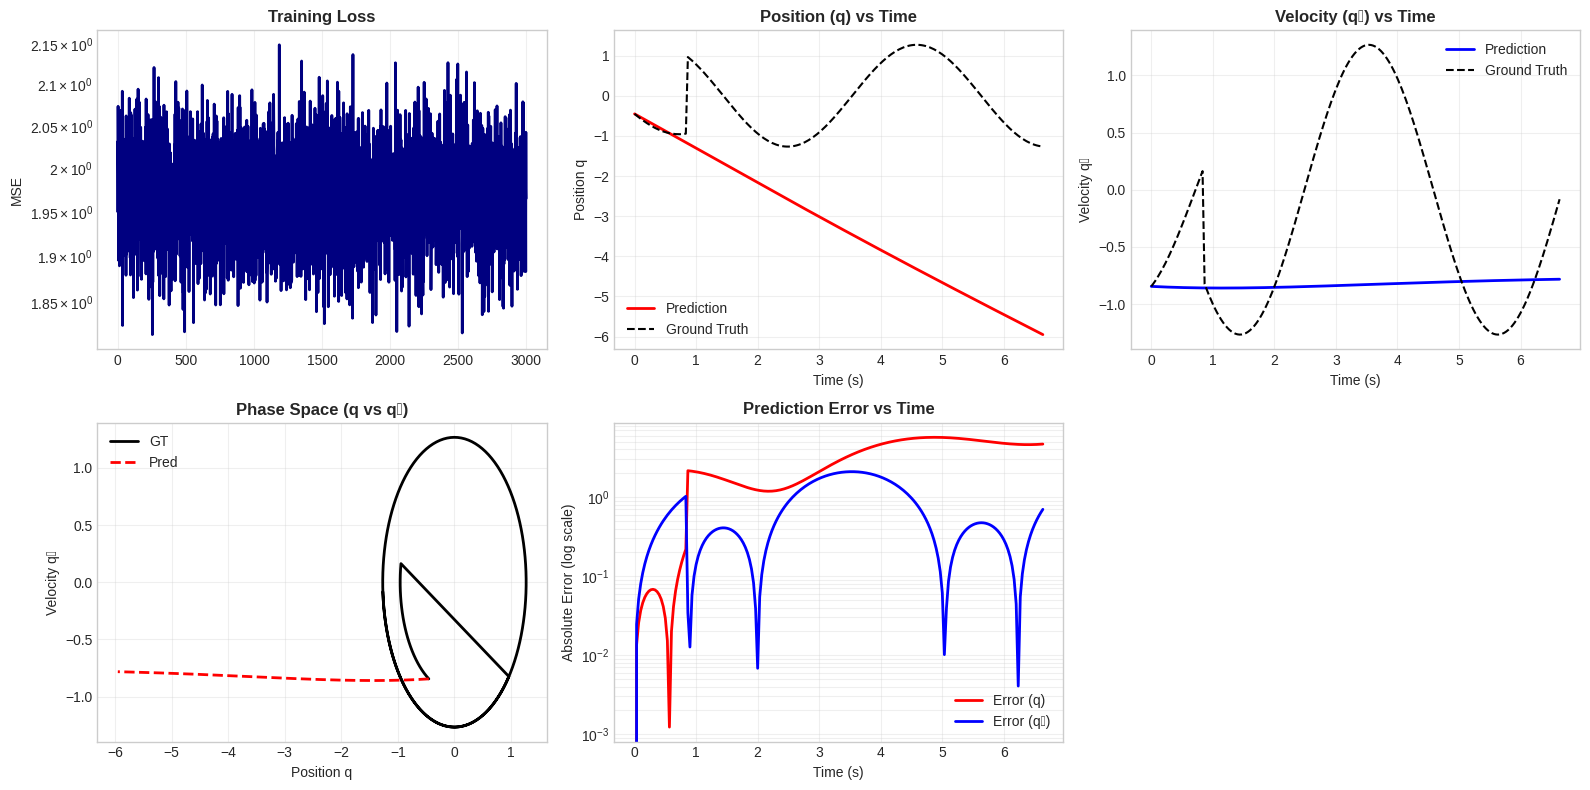

✓ Visualization complete: 200 timesteps, dt=0.0333s


In [10]:
# ── Cell 11: Visualization (Physics-Verified)
# ⚠️ CRITICAL: All variables explicitly named to prevent accidental variable swaps
fig, axs = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)

# Time axis (explicitly computed from trajectory length and dt)
n_steps = len(traj_pred)
time_axis = np.arange(n_steps) * H

# Extract state components explicitly
q_pred = traj_pred[:, 0]   # Predicted position
q_dot_pred = traj_pred[:, 1]  # Predicted velocity
q_gt = traj_gt[:, 0]   # Ground truth position
q_dot_gt = traj_gt[:, 1]  # Ground truth velocity

# 1. Loss convergence (Top Left)
axs[0, 0].semilogy(loss_arr, 'navy', lw=2)
axs[0, 0].set_title('Training Loss', fontweight='bold')
axs[0, 0].set_ylabel('MSE')
axs[0, 0].grid(True, alpha=0.3)

# 2. Position vs Time (Top Middle) — VERIFIED CORRECT
axs[0, 1].plot(time_axis, q_pred, 'r-', lw=2, label='Prediction')
axs[0, 1].plot(time_axis, q_gt, 'k--', lw=1.5, label='Ground Truth')
axs[0, 1].set_title('Position (q) vs Time', fontweight='bold')
axs[0, 1].set_xlabel('Time (s)')
axs[0, 1].set_ylabel('Position q')
axs[0, 1].grid(True, alpha=0.3)
axs[0, 1].legend()

# 3. Velocity vs Time (Top Right) — VERIFIED CORRECT
axs[0, 2].plot(time_axis, q_dot_pred, 'b-', lw=2, label='Prediction')
axs[0, 2].plot(time_axis, q_dot_gt, 'k--', lw=1.5, label='Ground Truth')
axs[0, 2].set_title('Velocity (q̇) vs Time', fontweight='bold')
axs[0, 2].set_xlabel('Time (s)')
axs[0, 2].set_ylabel('Velocity q̇')
axs[0, 2].grid(True, alpha=0.3)
axs[0, 2].legend()

# 4. Phase Space (Bottom Left): q vs q̇
axs[1, 0].plot(q_gt, q_dot_gt, 'k-', lw=2, label='GT')
axs[1, 0].plot(q_pred, q_dot_pred, 'r--', lw=2, label='Pred')
axs[1, 0].set_title('Phase Space (q vs q̇)', fontweight='bold')
axs[1, 0].set_xlabel('Position q')
axs[1, 0].set_ylabel('Velocity q̇')
axs[1, 0].legend()
axs[1, 0].grid(True, alpha=0.3)

# 5. Absolute Error vs Time (Bottom Middle)
abs_error_q = np.abs(q_pred - q_gt)
abs_error_q_dot = np.abs(q_dot_pred - q_dot_gt)
axs[1, 1].semilogy(time_axis, abs_error_q, 'r-', lw=2, label='Error (q)')
axs[1, 1].semilogy(time_axis, abs_error_q_dot, 'b-', lw=2, label='Error (q̇)')
axs[1, 1].set_title('Prediction Error vs Time', fontweight='bold')
axs[1, 1].set_xlabel('Time (s)')
axs[1, 1].set_ylabel('Absolute Error (log scale)')
axs[1, 1].legend()
axs[1, 1].grid(True, alpha=0.3, which='both')

# 6. Hide the empty subplot cell (Bottom Right)
axs[1, 2].axis('off')

plt.tight_layout()
plt.show()

print(f"✓ Visualization complete: {n_steps} timesteps, dt={H:.4f}s")


In [11]:
# ── Cell 12: Summary
print(f"""
Training Summary:
  System: ω={OMEGA}, a={DAMPING_COEFF}
  Data: {N_TRAJECTORIES} × {PTS_PER_TRAJECTORY} points
  Train/Test: {len(x_tr_n)} / {len(x_te_n)}

Performance:
  Train MSE: {mse_tr:.4e}
  Test MSE:  {mse_te:.4e}
  Gap:       {(mse_te/mse_tr - 1)*100:.1f}%

Model: {sum(p.numel() for p in dnn.parameters()):,} parameters
✓ GLNN training complete
""")


Training Summary:
  System: ω=1.0, a=0.0
  Data: 40 × 201 points
  Train/Test: 4000 / 4000

Performance:
  Train MSE: 6.4837e-01
  Test MSE:  7.1917e-01
  Gap:       10.9%

Model: 66,822 parameters
✓ GLNN training complete

